# Single-axis SMA scan

Fifty runs of the same minimal LEO mission, one per semi-major-axis value across `np.linspace(7000, 8000, 50)`, fanned out in parallel and overlaid on a single altitude-vs-time plot.

The smallest end-to-end exercise of the public API: one [`sweep()`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.sweep) call returns a `(run_id, time)`-MultiIndexed DataFrame; the plot below loops over `run_id` and overlays each per-run trajectory.

**Prerequisites.** A local GMAT install (R2026a is the primary development target; see [Supported versions](https://astro-tools.github.io/gmat-sweep/supported-versions/)) and `pip install gmat-sweep[examples]` for the matplotlib dependency.

## Set up the run

Resolve the GMAT install once and confirm the script that ships next to this notebook is where we expect it. The script lives in the same directory so the path is machine-independent.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from gmat_run import locate_gmat

from gmat_sweep import sweep

install = locate_gmat()
script_path = Path("leo_keplerian.script").resolve()

print(f"GMAT version: {install.version}")
print(f"Script:       {script_path.name}")
print(f"Exists:       {script_path.exists()}")

GMAT version: R2026a
Script:       leo_keplerian.script
Exists:       True


## Define the grid

Fifty semi-major-axis values, evenly spaced from 7000 km (~622 km altitude) to 8000 km (~1622 km altitude). The grid is a plain dict from dotted-path field name to an iterable of values; `sweep()` materialises the cartesian product internally.

In [2]:
sma_values = np.linspace(7000.0, 8000.0, 50)
sma_values

array([7000.        , 7020.40816327, 7040.81632653, 7061.2244898 ,
       7081.63265306, 7102.04081633, 7122.44897959, 7142.85714286,
       7163.26530612, 7183.67346939, 7204.08163265, 7224.48979592,
       7244.89795918, 7265.30612245, 7285.71428571, 7306.12244898,
       7326.53061224, 7346.93877551, 7367.34693878, 7387.75510204,
       7408.16326531, 7428.57142857, 7448.97959184, 7469.3877551 ,
       7489.79591837, 7510.20408163, 7530.6122449 , 7551.02040816,
       7571.42857143, 7591.83673469, 7612.24489796, 7632.65306122,
       7653.06122449, 7673.46938776, 7693.87755102, 7714.28571429,
       7734.69387755, 7755.10204082, 7775.51020408, 7795.91836735,
       7816.32653061, 7836.73469388, 7857.14285714, 7877.55102041,
       7897.95918367, 7918.36734694, 7938.7755102 , 7959.18367347,
       7979.59183673, 8000.        ])

## Run the sweep

One [`sweep()`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.sweep) call dispatches all 50 runs through the default `LocalJoblibPool`, drains the per-run outcomes in completion order, and returns the aggregated `(run_id, time)`-MultiIndexed DataFrame.

Each row carries the corresponding `Sat.SMA` override applied to that run, the `__status` column (`ok` / `failed` / `skipped`), and one column per channel the script's `ReportFile` declared. With `out=None` the per-run Parquet files land in a temporary directory whose lifetime is tied to the returned DataFrame.

In [3]:
df = sweep(script_path, grid={"Sat.SMA": sma_values}, workers=-1, progress=False)
df.head()

Sat.UTCGregorian        Sat.X  \
run_id time                                                           
0      2026-01-01 12:00:00.000 2026-01-01 12:00:00.000 -5936.162915   
       2026-01-01 12:01:00.000 2026-01-01 12:01:00.000 -6040.931768   
       2026-01-01 12:04:39.743 2026-01-01 12:04:39.743 -6206.113475   
       2026-01-01 12:08:32.899 2026-01-01 12:08:32.899 -6001.419050   
       2026-01-01 12:12:26.328 2026-01-01 12:12:26.328 -5417.739050   

                                      Sat.Y        Sat.Z __status  
run_id time                                                        
0      2026-01-01 12:00:00.000  1590.590059  3336.771210       ok  
       2026-01-01 12:01:00.000  1149.786937  3329.772890       ok  
       2026-01-01 12:04:39.743  -491.581464  3185.746222       ok  
       2026-01-01 12:08:32.899 -2201.001458  2838.173086       ok  
       2026-01-01 12:12:26.328 -3773.474882  2311.083824       ok

Confirm every run finished cleanly. Failed and skipped runs would surface as one NaN-filled row each, with `__status` set accordingly.

In [4]:
df["__status"].value_counts()

__status
ok    813
Name: count, dtype: int64

## Derive altitude and overlay

The script's ReportFile records inertial position only (`Sat.X`, `Sat.Y`, `Sat.Z`) — altitude is a derived quantity. For a spherical Earth it's $|\mathbf{r}| - R_\oplus$. We compute it on the whole frame in one vectorised pass; the `(run_id, time)` MultiIndex carries through unchanged.

In [5]:
EARTH_RADIUS_KM = 6378.137  # WGS-84 equatorial radius

position = df[["Sat.X", "Sat.Y", "Sat.Z"]]
df["Altitude_km"] = (position**2).sum(axis=1) ** 0.5 - EARTH_RADIUS_KM

Overlay every run on a single axis. Grouping by `run_id` lets us iterate one trajectory at a time; we colour each line by its commanded `Sat.SMA` so the visual sweep matches the parameter sweep.

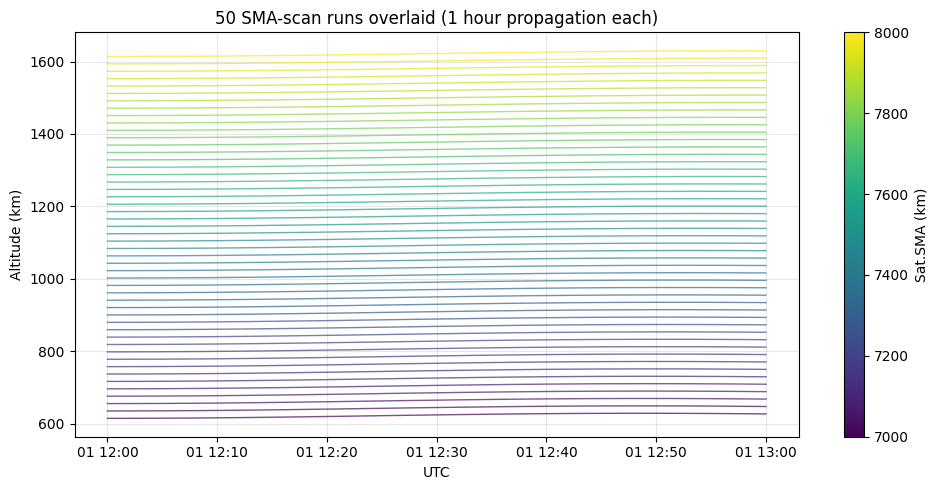

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.get_cmap("viridis")

for run_id, group in df.groupby(level="run_id"):
    sma = sma_values[run_id]
    color = cmap((sma - sma_values.min()) / (sma_values.max() - sma_values.min()))
    times = group.index.get_level_values("time")
    ax.plot(times, group["Altitude_km"], color=color, alpha=0.7, linewidth=1.0)

norm = plt.Normalize(vmin=sma_values.min(), vmax=sma_values.max())
fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    label="Sat.SMA (km)",
)
ax.set_xlabel("UTC")
ax.set_ylabel("Altitude (km)")
ax.set_title("50 SMA-scan runs overlaid (1 hour propagation each)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Where to next

- **Two-axis grids.** [Notebook 02](https://astro-tools.github.io/gmat-sweep/examples/02_epoch_arrival_grid/) adds a second sweep axis (launch epoch × time-of-flight) and contours a per-run scalar across the grid.
- **Inspect a partial sweep after a kill.** [Notebook 03](https://astro-tools.github.io/gmat-sweep/examples/03_killed_sweep_recovery/) demonstrates that the JSON Lines manifest survives a mid-sweep `Ctrl-C` and can be loaded back from disk.
- **Keep the per-run Parquet files.** Pass `out=Path("./sweep-out")` to [`sweep()`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.sweep) to anchor the per-run artefacts under an explicit directory instead of a temp dir.
- **CLI alternative.** The [`gmat-sweep run`](https://astro-tools.github.io/gmat-sweep/parameter-spec/) shell command wraps the same call for non-Python pipelines.